1. Load & inspect    → pd.read_csv, .head(), .info(), .describe()
2. Handle nulls      → .fillna(median/mode), SimpleImputer, KNNImputer  
3. Encode categories → OrdinalEncoder, OneHotEncoder, target encoding
4. Scale features    → StandardScaler, RobustScaler, MinMaxScaler
5. Split data        → train_test_split, KFold, StratifiedKFold
6. Train & evaluate  → .fit(), .predict(), cross_val_score

## Recall  Day 1:
1. When do you use RobustScaler over StandardScaler?

     - in case of linear models the mean will be dragged way further due to outliers like $2 million SalePrice
     - and thus hamper our predictive model. RobustScaler provides a better appraoch considers median and IQR ahd thus considering middle 50% data.
     - Whereas StandardScaler does scale around mean =0, sd =1

2. Why does target encoding need to be calculated inside CV folds?
    -  Target Encoding we remove the categorical variables and replace them with the most descriptive features mean
    -  data leakage : if you calculate neighborhood means using the full dataset including validation rows, those validation rows have already influenced the encoding before the model sees them.
    - The model gets a sneak peek at the target. CV folds prevent this by calculating means only from training rows.

3. OrdinalEncoder vs OneHotEncoder
    - OrdinalEncoder : assumes ranking between the categorcial features.
        - USe this when there is ordered data and it needs to be showcased like high, medium, low.  

    - OneHotEncoder to encode categorcial values which may be unordered

#**Week 5 Day 2**



1.	Missing data: SimpleImputer (mean/median/mode), KNNImputer : compare on Titanic
2.	Feature creation: interaction terms, polynomial features, log transforms for skewed cols
3.	Date features: extract year, month, day, day-of-week, is-weekend from a datetime column


In [38]:
import pandas as pd
import numpy as np

df = pd.read_csv("train.csv")

In [39]:
null_cols = df.isnull().sum()
null_cols[null_cols > 0].sort_values(ascending=False)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


In [40]:
#drop cols > 50% null count
df = df.drop(columns=["PoolQC", "MiscFeature", "Alley", "Fence", "MasVnrType"])

In [41]:
#Fill na values of numeric columns with median
for cols in df.select_dtypes(include='number').columns:
  df[cols] = df[cols].fillna(df[cols].median())


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 76 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [43]:
#fill categorical columns with mode
for cols in df.select_dtypes(include='object').columns:
  df[cols] = df[cols].fillna(df[cols].mode()[0])

## Task 1
1. SimpleImputer Load Titanic raw, impute Age with mean, median, and mode separately.
2. Compare the three distributions with a plot. Which changes the shape least?

In [44]:
df_titanic = pd.read_csv("train_tit.csv")

In [45]:
X = df_titanic.drop(columns="Survived")
y = df_titanic['Survived']

In [46]:
X

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [47]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [48]:
nulls = df_titanic.isnull().sum()
nulls.sort_values(ascending=False)

,0
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0


In [49]:
from sklearn.impute import SimpleImputer

imp_mean = SimpleImputer(strategy= "mean")
imp_mode = SimpleImputer(strategy= "most_frequent")
imp_median = SimpleImputer(strategy= "median")

y_mean = imp_mean.fit_transform(df_titanic['Age'].values.reshape(-1,1))
y_mode = imp_mode.fit_transform(df_titanic['Age'].values.reshape(-1,1))
y_median = imp_median.fit_transform(df_titanic['Age'].values.reshape(-1,1))
print("--")

--


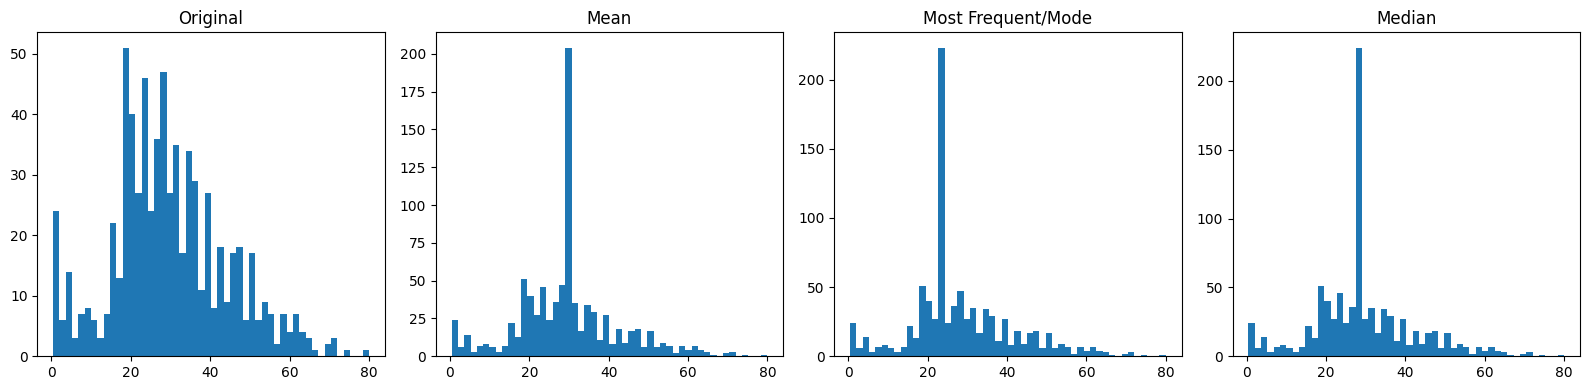

In [50]:
import matplotlib.pyplot as plt

fig,ax = plt.subplots(1,4,figsize=(16,4))

ax[0].hist(df_titanic['Age'],bins=50)
ax[0].set_title("Original")

ax[1].hist(y_mean,bins=50)
ax[1].set_title("Mean")

ax[2].hist(y_mode, bins=50)
ax[2].set_title("Most Frequent/Mode")

ax[3].hist(y_median, bins=50)
ax[3].set_title("Median")

plt.tight_layout()
plt.show()

1. Original: natural distribution, right-skewed, peaks around 20-30
2. Mean: massive spike at ~29 where all 177 missing values got filled with the same mean value
3. Most Frequent: spike at ~24 (most common age in dataset)
4. Median: spike at ~28, very similar to mean since Age isn't extremely skewed

### Task 2 :
- KNNImputer Impute Age using KNNImputer(n_neighbors=5).


In [51]:
from sklearn.impute import KNNImputer


# KNN needs all numeric features
X_numeric = df_titanic[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']]



knn_impute  = KNNImputer(n_neighbors=5)
knn_impute.fit_transform(X_numeric)

array([[ 3.    , 22.    ,  1.    ,  0.    ,  7.25  ],
       [ 1.    , 38.    ,  1.    ,  0.    , 71.2833],
       [ 3.    , 26.    ,  0.    ,  0.    ,  7.925 ],
       ...,
       [ 3.    , 26.8   ,  1.    ,  2.    , 23.45  ],
       [ 1.    , 26.    ,  0.    ,  0.    , 30.    ],
       [ 3.    , 32.    ,  0.    ,  0.    ,  7.75  ]])

#### KNNImputer : fills missing value with mean of K most similar rows
  -  Similarity = Euclidean distance across all other features
  - Better than SimpleImputer when missingness correlates with other features


1. Compare to SimpleImputer mean.


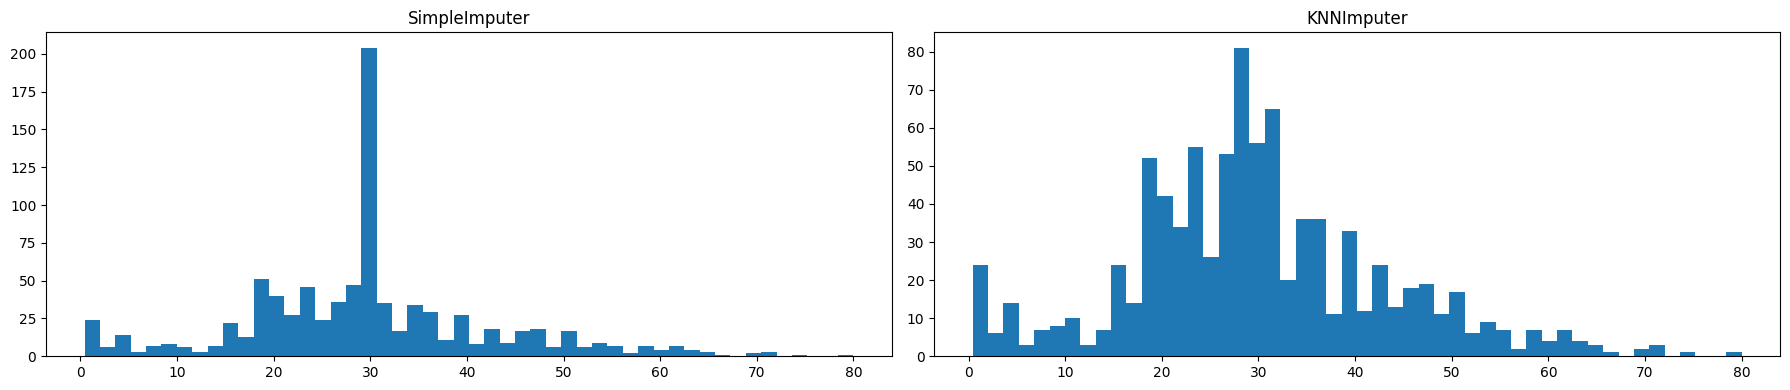

In [52]:
y_KNN = knn_impute.fit_transform(X_numeric)

fig,ax = plt.subplots(1,2,figsize=(18,4))

ax[0].hist(y_mean, bins=50)
ax[0].set_title("SimpleImputer")

ax[1].hist(y_KNN[:,1], bins = 50)
ax[1].set_title("KNNImputer")

plt.tight_layout()
plt.show()

#### SimpleImputer: massive spike at 30
  - all 177 missing values got the same number.

#### KNNImputer: small bump around 28-32 but smooth overall
 - each missing value got a different fill based on its 5 nearest neighbours.
 - Distribution looks much closer to the original.

2. Which RMSE is lower when you train a RandomForest after each?


In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

#1. Build X with imputed Age replacing original
X_knn = pd.DataFrame(y_KNN, columns= X_numeric.columns)



rf = RandomForestClassifier(random_state= 42)
score = cross_val_score(rf, X_knn, y, cv=5)
print(np.mean(score))

0.6824116502416672


In [54]:
X_simpleImputer  = X_numeric.copy()

X_simpleImputer["Age"] = y_mean.flatten()

score_simple = cross_val_score(rf, X_simpleImputer, y, cv= 5)
print(np.mean(score_simple))

0.6734228861967234


## 3.  SimpleImputer vs KNNImputer

1. SimpleImputer:
- Fast, simple, works well when missingness is random
- and the missing feature has low correlation with other features.
- Creates artificial spike at mean/median :distorts distribution.

2. KNNImputer:
- Better when missingness correlates with other features
- (e.g. Age correlates with Pclass and Fare in Titanic).
 - Fills each missing value with the mean of K most similar rows based on Euclidean distance across other features.
 - Produces smoother, more realistic distribution : proved by 0.682 vs 0.673 CV score on Titanic.

#### Rule:
1. Default to SimpleImputer for speed.
2. Use KNNImputer when you suspect the missing feature correlates with other features in your dataset.

### Task 3
1. Feature creation On House Prices:
- create TotalSF = GrLivArea + TotalBsmtSF,
- polynomial feature OverallQual²,
- log transform LotArea.
2.  Do these improve XGBoost CV score?


In [55]:
df['TotalSf'] = df['GrLivArea'] + df['TotalBsmtSF']


df['OverallQual_sq'] = df['OverallQual'] **2
df['LogLotArea'] = np.log1p(df['LotArea'])

In [56]:
df = pd.get_dummies(df)

X_housing = df.drop(columns=['SalePrice'])
y_housing = df['SalePrice']

In [57]:
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score


model = XGBRegressor(n_estimators = 417, max_depth = 3, learning_rate =0.135)

scores = cross_val_score(model, X_housing, y_housing, cv=5, scoring='neg_mean_squared_error')
print(np.mean(scores))

-675983411.2


In [58]:
print(f"RMSE: ${np.sqrt(abs(np.mean(scores))):,.0f}")

RMSE: $26,000


## Feature Engineering Results

| Change | RMSE | Delta |
|--------|------|-------|
| XGBoost + Optuna baseline | 26,305 | — |
| + TotalSF, OverallQual², LogLotArea | 26,000 | -305 |

## Key insight:
1. Combining correlated features (TotalSF) and capturing
non-linear relationships (OverallQual²) gave marginal but consistent
improvement.
2. Feature engineering gains show small improvements
compound across many engineered features.

- Interaction terms (TotalSF): Combines GrLivArea + TotalBsmtSF.
 1. Keeping originals + TotalSF (\$26,000) outperformed
 2. dropping originals (\$26,091) individual components still carry unique signal beyond sum.


### Task 4
- Date features Create a synthetic datetime column, extract year, month, day, day-of-week, is-weekend.


In [59]:
df_dates = pd.DataFrame({
    'date': pd.date_range('2020-01-01', periods=10, freq='D')
})

In [60]:
# Extract year, month, day, day-of-week, is-weekend.

df_dates['year'] = df_dates['date'].dt.year
df_dates['month']= df_dates['date'].dt.month
df_dates['day'] = df_dates['date'].dt.day
df_dates['day_of_week']  = df_dates['date'].dt.day_of_week
df_dates['is_weekend']= df_dates['date'].dt.day_of_week >= 5

In [61]:
df_dates

,date,year,month,day,day_of_week,is_weekend
0,2020-01-01,2020,1,1,2,False
1,2020-01-02,2020,1,2,3,False
2,2020-01-03,2020,1,3,4,False
3,2020-01-04,2020,1,4,5,True
4,2020-01-05,2020,1,5,6,True
5,2020-01-06,2020,1,6,0,False
6,2020-01-07,2020,1,7,1,False
7,2020-01-08,2020,1,8,2,False
8,2020-01-09,2020,1,9,3,False
9,2020-01-10,2020,1,10,4,False


### Imputers
- SimpleImputer: Fast baseline. Use when missingness is random and
  the feature has low correlation with others.
- KNNImputer: Use when missing values correlate with other features.
  Fills each value using mean of K nearest rows by Euclidean distance.
  Produces realistic distribution vs artificial spike from SimpleImputer.

### Feature Engineering
- Interaction terms (TotalSF): Combines correlated features into one
  stronger signal, total living space more predictive than parts alone.
- Polynomial features (OverallQual²): Captures non-linear relationships.
  Jump from quality 8→9 is worth more than 1→2. Linear models miss this.
- Log transform (LogLotArea): Compresses right skew, spreads values evenly,
  gives model better split points across full range.

### Date Features
Raw dates are strings: no mathematical relationship for model to learn.
- Extracting year,
- month(seasonality (house prices higher in spring)),
-  dayofweek [weekly patterns (more sales on weekends)\]
- is_weekend
- creates numeric signals capturing seasonality and weekly patterns the model can split on directly.